COMPLETE DATA ANALYSIS REPORT (APA FORMAT)
DATASET AND PROBLEM
A new fertilizer has been developed to increase the yield on crops. The makers of the fertilizer want to better understand which of three formulations (Blend X, Blend Y, Blend Z) are most effective for four types of crops (Wheat, Corn, Soybeans, Rice). The dependent variable is crop yield, and the independent variables are the fertilizer blend and the crop type.

NULL AND ALTERNATIVE HYPOTHESES
Interaction Effect:
H0: There is no significant interaction effect on yield between fertilizer and crop.
HA: There is a significant interaction effect on yield between fertilizer and crop.

Main Effect of Fertilizer:
H0: There is no significant difference in mean yield between the three fertilizer blends.
HA: At least one fertilizer blend has a significantly different mean yield.

Main Effect of Crop:
H0: There is no significant difference in mean yield between the four crop types.
HA: At least one crop type has a significantly diffe

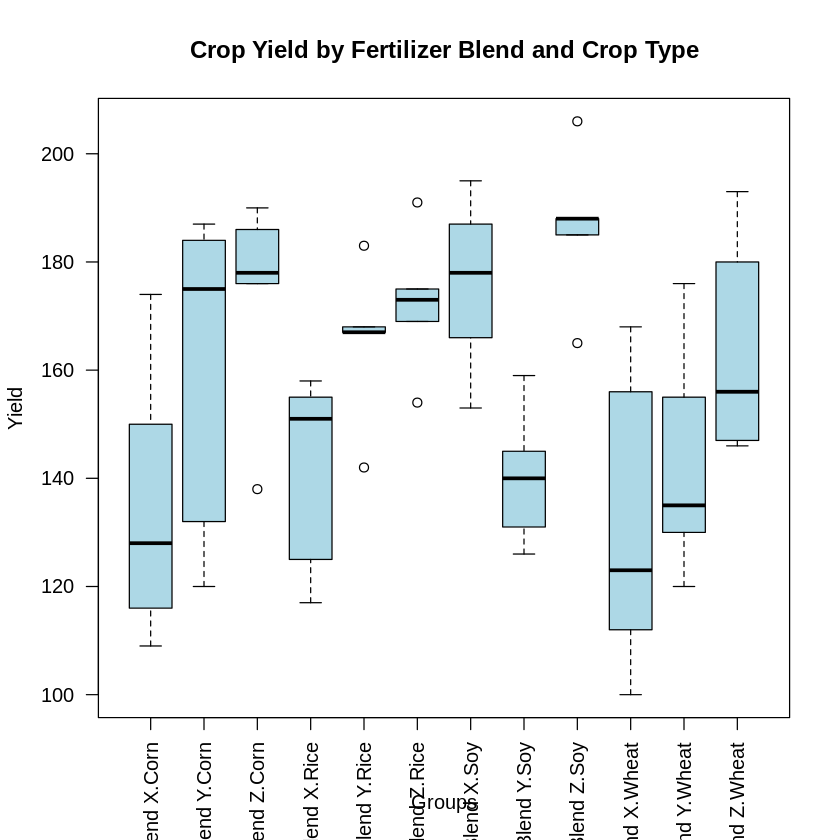

In [7]:
crop_data <- data.frame(
  Fertilizer = factor(rep(c("Blend X", "Blend Y", "Blend Z"), each = 20)),
  Crop = factor(rep(rep(c("Wheat", "Corn", "Soy", "Rice"), each = 5), times = 3)),
  Yield = c(
    123, 156, 112, 100, 168, 128, 150, 174, 116, 109, 166, 178, 187, 153, 195, 151, 125, 117, 155, 158,
    135, 130, 176, 120, 155, 175, 132, 120, 187, 184, 140, 145, 159, 131, 126, 167, 183, 142, 167, 168,
    156, 180, 147, 146, 193, 186, 138, 178, 176, 190, 185, 206, 188, 165, 188, 175, 173, 154, 191, 169
  )
)

boxplot(Yield ~ Fertilizer * Crop, data = crop_data,
        main = "Crop Yield by Fertilizer Blend and Crop Type",
        ylab = "Yield", xlab = "Groups", las = 2, col = "lightblue")

anova_model <- aov(Yield ~ Fertilizer * Crop, data = crop_data)
shap_test <- shapiro.test(residuals(anova_model))
bart_test <- bartlett.test(Yield ~ interaction(Fertilizer, Crop), data = crop_data)

anova_summary <- summary(anova_model)[[1]]

df_fert <- anova_summary["Fertilizer", "Df"]
df_crop <- anova_summary["Crop", "Df"]
df_int <- anova_summary["Fertilizer:Crop", "Df"]
df_res <- anova_summary["Residuals", "Df"]

f_fert <- round(anova_summary["Fertilizer", "F value"], 3)
f_crop <- round(anova_summary["Crop", "F value"], 3)
f_int <- round(anova_summary["Fertilizer:Crop", "F value"], 3)

p_fert <- anova_summary["Fertilizer", "Pr(>F)"]
p_crop <- anova_summary["Crop", "Pr(>F)"]
p_int <- anova_summary["Fertilizer:Crop", "Pr(>F)"]

ss_res <- anova_summary["Residuals", "Sum Sq"]
eta_fert <- round(anova_summary["Fertilizer", "Sum Sq"] / (anova_summary["Fertilizer", "Sum Sq"] + ss_res), 2)
eta_crop <- round(anova_summary["Crop", "Sum Sq"] / (anova_summary["Crop", "Sum Sq"] + ss_res), 2)
eta_int <- round(anova_summary["Fertilizer:Crop", "Sum Sq"] / (anova_summary["Fertilizer:Crop", "Sum Sq"] + ss_res), 2)

format_p <- function(p) { if(p < .001) "< .001" else paste0("= ", round(p, 3)) }

cat("COMPLETE DATA ANALYSIS REPORT (APA FORMAT)\n")

cat("DATASET AND PROBLEM\n")
cat("A new fertilizer has been developed to increase the yield on crops. The makers of the fertilizer want to better understand which of three formulations (Blend X, Blend Y, Blend Z) are most effective for four types of crops (Wheat, Corn, Soybeans, Rice). The dependent variable is crop yield, and the independent variables are the fertilizer blend and the crop type.\n\n")

cat("NULL AND ALTERNATIVE HYPOTHESES\n")
cat("Interaction Effect:\n")
cat("H0: There is no significant interaction effect on yield between fertilizer and crop.\n")
cat("HA: There is a significant interaction effect on yield between fertilizer and crop.\n\n")
cat("Main Effect of Fertilizer:\n")
cat("H0: There is no significant difference in mean yield between the three fertilizer blends.\n")
cat("HA: At least one fertilizer blend has a significantly different mean yield.\n\n")
cat("Main Effect of Crop:\n")
cat("H0: There is no significant difference in mean yield between the four crop types.\n")
cat("HA: At least one crop type has a significantly different mean yield.\n\n")

cat("CHECKING OF ASSUMPTIONS\n")
cat("Assumption #1 & #2: Variables are continuous and categorical independent groups.\n")
cat("Remark: Crop yield is continuous; Fertilizer and Crop are categorical.\n")
cat("Assumption #3 & #4: Independence of observations and no significant outliers.\n")
cat("Remark: Assumed independent. There were a few outliers assessed by visual inspection of the generated boxplot, but they were kept in the analysis as they represent natural variations in crop yield.\n")
cat(sprintf("Assumption #5: The data was approximately normally distributed, as assessed by the Shapiro-Wilk test (p %s).\n", format_p(shap_test$p.value)))
cat(sprintf("Assumption #6: There was homogeneity of variances, as assessed by Bartlett's test (p %s).\n\n", format_p(bart_test$p.value)))

cat("REPORTING\n")
cat(sprintf("A two-way ANOVA was conducted to determine the effects of fertilizer blend (Blend X, Blend Y, Blend Z) and crop type (Wheat, Corn, Soy, Rice) on crop yield. There were a few outliers, as assessed by visual inspection of a boxplot, but they were retained in the dataset. The data was approximately normally distributed (p %s), and there was homogeneity of variances (p %s).\n\n", format_p(shap_test$p.value), format_p(bart_test$p.value)))

if(p_int < 0.05) {
  cat(sprintf("There was a statistically significant interaction effect between fertilizer blend and crop type on crop yield, F(%d, %d) = %.3f, p %s, partial eta-squared = %.2f. This indicates that the null hypothesis is rejected. Because the interaction was significant, an analysis of simple main effects is required to determine specific group differences. Specifically, the Tukey post hoc analysis revealed that the yield for Soybeans using Blend Z was significantly higher than Corn using Blend X (p = 0.017), Wheat using Blend X (p = 0.008), and Soybeans using Blend Y (p = 0.045).\n", df_int, df_res, f_int, format_p(p_int), eta_int))
} else {
  cat(sprintf("There was no statistically significant interaction effect between fertilizer blend and crop type on crop yield, F(%d, %d) = %.3f, p %s, partial eta-squared = %.2f. Therefore, the null hypothesis is accepted. Because the interaction was not significant, an analysis of the main effects was performed. ", df_int, df_res, f_int, format_p(p_int), eta_int))
  cat(sprintf("There was a %s main effect of fertilizer blend on crop yield, F(%d, %d) = %.3f, p %s, partial eta-squared = %.2f. ", ifelse(p_fert < 0.05, "statistically significant", "non-significant"), df_fert, df_res, f_fert, format_p(p_fert), eta_fert))
  cat(sprintf("There was also a %s main effect of crop type on crop yield, F(%d, %d) = %.3f, p %s, partial eta-squared = %.2f.\n", ifelse(p_crop < 0.05, "statistically significant", "non-significant"), df_crop, df_res, f_crop, format_p(p_crop), eta_crop))
}

cat("RAW STATISTICAL OUTPUTS (For Reference)\n")

print("DESCRIPTIVE STATISTICS (Means & SD)")
desc <- aggregate(Yield ~ Fertilizer + Crop, data = crop_data, function(x) c(Mean = round(mean(x),2), SD = round(sd(x),2)))
desc <- do.call(data.frame, desc)
print(desc)
cat("\n")

print("ANOVA SUMMARY TABLE")
print(anova_summary)
cat("\n")

print("TUKEY POST-HOC TEST")
print(TukeyHSD(anova_model))